# DMEPOS Amount stats exploration

In this workbook we engineer a new set of features calculating mean, median, minimum, maximum, and standard deviation of numeric data fields for each unique NPI aggregated by program year. We also engineer an additional two features, `tot_suplr_nonrntl_hcpcs_cds` and `tot_suplr_rentl_hcpcs_cds` corresponding to the count of unique HCPCS codes with the negative and positive rental tag respectively for each unique NPI aggregated by the program year.

## WARNING! The following notebooks must be run before this one.
* SpIn_1_Artifacts/one_specialty_per_npi_silver.ipynb
* SpIn_2_Artifacts/dmepos_rfrhpr_labeled_silver.ipynb
* SpIn_2_Artifacts/dmepos_rfrr_labeled_silver.ipynb

# Data Aggregation/Feature Engineering

In [1]:
import pandas as pd

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

# read-in the dataset for validation
df_validate = pd.read_csv('/dsa/groups/casestudycf25/team02/silver/dmepos_rfrhpr_labeled.csv',dtype={'rfrg_prvdr_state_fips':str,'rfrg_prvdr_zip5':str})
df_validate.head()

,npi,rfrg_prvdr_last_name_org,rfrg_prvdr_first_name,rfrg_prvdr_mi,rfrg_prvdr_crdntls,rfrg_prvdr_ent_cd,rfrg_prvdr_st1,rfrg_prvdr_st2,rfrg_prvdr_city,rfrg_prvdr_state_abrvtn,rfrg_prvdr_state_fips,rfrg_prvdr_zip5,rfrg_prvdr_ruca_cat,rfrg_prvdr_ruca,rfrg_prvdr_ruca_desc,rfrg_prvdr_cntry,rfrg_prvdr_spclty_cd,rfrg_prvdr_spclty_desc,rfrg_prvdr_spclty_srce,rbcs_lvl,rbcs_id,rbcs_desc,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplrs,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt,year,aapc_desc,tot_suplr_mdcr_pymt_amt,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat,target
0,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DC000N,DME-Oxygen and Supplies,E0431,"Portable gaseous oxygen system, rental; includ...",Y,5,5.0,16,16,46.336250,20.097500,14.857500,15.280000,2021,Oxygen Delivery Systems and Related Supplies,237.72,-0.425926,0.955638,0
1,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DC002N,DME-Oxygen and Supplies,E1390,"Oxygen concentrator, single delivery port, cap...",Y,6,5.0,19,19,360.770000,98.223158,72.843684,79.753158,2021,Accessories for Oxygen Delivery Devices,1384.03,-0.347468,0.942913,0
2,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DD000N,DME-Wheelchairs,K0002,Standard hemi (low seat) wheelchair,Y,1,5.0,11,11,92.000000,39.230000,31.385455,33.552727,2021,"Wheelchairs, Components, and Accessories",345.24,-0.390508,0.985031,0
3,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DD021N,DME-Wheelchairs,K0195,"Elevating leg rests, pair (for use with capped...",Y,1,5.0,11,11,20.000000,10.210909,8.169091,8.456364,2021,"Wheelchairs, Components, and Accessories",89.86,-0.409305,1.022396,0
4,1003000480,Rothchild,Kevin,B,md,I,12605 E 16th Ave,NaN,Aurora,CO,08,80045,Urban,1.0,Metropolitan area core: primary flow within an...,US,02,general_surgery,Claim-Specialty,Durable Medical Equipment,DC002N,DME-Oxygen and Supplies,E1390,"Oxygen concentrator, single delivery port, cap...",Y,4,5.0,11,13,272.003846,80.513846,64.407692,84.701538,2021,Accessories for Oxygen Delivery Devices,837.30,-0.419031,0.772909,0


## Indicate if tot_suplr_clms, if tot_suplr_srvcs, and if tot_suplr_mdcr_pymt_amt are above the 90th percentile for the given service, rental indicator, and year

In [2]:
df_validate['tot_suplr_clms_hcpcs_rentl_ind_pctl'] = df_validate.groupby(['hcpcs_cd','suplr_rentl_ind','year'])['tot_suplr_clms'].rank(pct=True)
df_validate['tot_suplr_srvcs_hcpcs_rentl_ind_pctl'] = df_validate.groupby(['hcpcs_cd','suplr_rentl_ind','year'])['tot_suplr_srvcs'].rank(pct=True)
df_validate['tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl'] = df_validate.groupby(['hcpcs_cd','suplr_rentl_ind','year'])['tot_suplr_mdcr_pymt_amt'].rank(pct=True)

In [3]:
df_validate['tot_suplr_clms_hcpcs_rentl_ind_pctl_abv_90'] = df_validate['tot_suplr_clms_hcpcs_rentl_ind_pctl'].apply(lambda x: 1 if x>0.9 else 0)
df_validate['tot_suplr_srvcs_hcpcs_rentl_ind_pctl_abv_90'] = df_validate['tot_suplr_srvcs_hcpcs_rentl_ind_pctl'].apply(lambda x: 1 if x>0.9 else 0)
df_validate['tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl_abv_90'] = df_validate['tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl'].apply(lambda x: 1 if x>0.9 else 0)
df_validate.head()

,npi,rfrg_prvdr_last_name_org,rfrg_prvdr_first_name,rfrg_prvdr_mi,rfrg_prvdr_crdntls,rfrg_prvdr_ent_cd,rfrg_prvdr_st1,rfrg_prvdr_st2,rfrg_prvdr_city,rfrg_prvdr_state_abrvtn,rfrg_prvdr_state_fips,rfrg_prvdr_zip5,rfrg_prvdr_ruca_cat,rfrg_prvdr_ruca,rfrg_prvdr_ruca_desc,rfrg_prvdr_cntry,rfrg_prvdr_spclty_cd,rfrg_prvdr_spclty_desc,rfrg_prvdr_spclty_srce,rbcs_lvl,rbcs_id,rbcs_desc,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplrs,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt,year,aapc_desc,tot_suplr_mdcr_pymt_amt,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat,target,tot_suplr_clms_hcpcs_rentl_ind_pctl,tot_suplr_srvcs_hcpcs_rentl_ind_pctl,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl,tot_suplr_clms_hcpcs_rentl_ind_pctl_abv_90,tot_suplr_srvcs_hcpcs_rentl_ind_pctl_abv_90,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl_abv_90
0,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DC000N,DME-Oxygen and Supplies,E0431,"Portable gaseous oxygen system, rental; includ...",Y,5,5.0,16,16,46.336250,20.097500,14.857500,15.280000,2021,Oxygen Delivery Systems and Related Supplies,237.72,-0.425926,0.955638,0,0.366360,0.346326,0.314866,0,0,0
1,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DC002N,DME-Oxygen and Supplies,E1390,"Oxygen concentrator, single delivery port, cap...",Y,6,5.0,19,19,360.770000,98.223158,72.843684,79.753158,2021,Accessories for Oxygen Delivery Devices,1384.03,-0.347468,0.942913,0,0.376232,0.361254,0.351235,0,0,0
2,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DD000N,DME-Wheelchairs,K0002,Standard hemi (low seat) wheelchair,Y,1,5.0,11,11,92.000000,39.230000,31.385455,33.552727,2021,"Wheelchairs, Components, and Accessories",345.24,-0.390508,0.985031,0,0.096573,0.095565,0.234879,0,0,0
3,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DD021N,DME-Wheelchairs,K0195,"Elevating leg rests, pair (for use with capped...",Y,1,5.0,11,11,20.000000,10.210909,8.169091,8.456364,2021,"Wheelchairs, Components, and Accessories",89.86,-0.409305,1.022396,0,0.079720,0.077712,0.220287,0,0,0
4,1003000480,Rothchild,Kevin,B,md,I,12605 E 16th Ave,NaN,Aurora,CO,08,80045,Urban,1.0,Metropolitan area core: primary flow within an...,US,02,general_surgery,Claim-Specialty,Durable Medical Equipment,DC002N,DME-Oxygen and Supplies,E1390,"Oxygen concentrator, single delivery port, cap...",Y,4,5.0,11,13,272.003846,80.513846,64.407692,84.701538,2021,Accessories for Oxygen Delivery Devices,837.30,-0.419031,0.772909,0,0.029000,0.189968,0.119993,0,0,0


## Engineer features aggregated by npi and year
### Note that it is also necessary to include the referring provider state and fraud label when grouping. We will later filter to Missouri and boarder states, and we want to preserve the labeling performed earlier.

We calculate mean, sum, median, minimum, and maximum of `avg_suplr_sbmtd_chrg`, `avg_suplr_medcr_alowd`, `avg_suplr_mdcr_pymt_amt`, `avg_suplr_mdcr_stdzd_amt`, `tot_suplr_mdcr_pymt_amt`, `tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr`, and `avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat` for each provider and year.

In [4]:
df_validate_eng = df_validate[['npi','rfrg_prvdr_state_abrvtn','avg_suplr_sbmtd_chrg','avg_suplr_mdcr_alowd_amt','avg_suplr_mdcr_pymt_amt','avg_suplr_mdcr_stdzd_amt','tot_suplr_mdcr_pymt_amt','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat','year','target']].groupby(['npi','rfrg_prvdr_state_abrvtn','year','target']).mean().reset_index()
df_validate_eng = df_validate_eng.rename(columns={'avg_suplr_sbmtd_chrg':'avg_suplr_sbmtd_chrg_mean','avg_suplr_mdcr_alowd_amt':'avg_suplr_mdcr_alowd_amt_mean','avg_suplr_mdcr_pymt_amt':'avg_suplr_mdcr_pymt_amt_mean','avg_suplr_mdcr_stdzd_amt':'avg_suplr_mdcr_stdzd_amt_mean','tot_suplr_mdcr_pymt_amt':'tot_suplr_mdcr_pymt_amt_mean','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr':'tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat':'avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean'})
df_validate_eng[['avg_suplr_sbmtd_chrg_sum','avg_suplr_mdcr_alowd_amt_sum','avg_suplr_mdcr_pymt_amt_sum','avg_suplr_mdcr_stdzd_amt_sum','tot_suplr_mdcr_pymt_amt_sum','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum']] = df_validate[['npi','rfrg_prvdr_state_abrvtn','avg_suplr_sbmtd_chrg','avg_suplr_mdcr_alowd_amt','avg_suplr_mdcr_pymt_amt','avg_suplr_mdcr_stdzd_amt','year','tot_suplr_mdcr_pymt_amt','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat','target']].groupby(['npi','rfrg_prvdr_state_abrvtn','year','target']).sum().reset_index(drop=True)
df_validate_eng[['avg_suplr_sbmtd_chrg_median','avg_suplr_mdcr_alowd_amt_median','avg_suplr_mdcr_pymt_amt_median','avg_suplr_mdcr_stdzd_amt_median','tot_suplr_mdcr_pymt_amt_median','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median']] = df_validate[['npi','rfrg_prvdr_state_abrvtn','avg_suplr_sbmtd_chrg','avg_suplr_mdcr_alowd_amt','avg_suplr_mdcr_pymt_amt','avg_suplr_mdcr_stdzd_amt','year','tot_suplr_mdcr_pymt_amt','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat','target']].groupby(['npi','rfrg_prvdr_state_abrvtn','year','target']).median().reset_index(drop=True)
# df_validate_eng[['avg_suplr_sbmtd_chrg_std','avg_suplr_mdcr_alowd_amt_std','avg_suplr_mdcr_pymt_amt_std','avg_suplr_mdcr_stdzd_amt_std']] = df_validate[['npi','rfrg_prvdr_state_abrvtn','avg_suplr_sbmtd_chrg','avg_suplr_mdcr_alowd_amt','avg_suplr_mdcr_pymt_amt','avg_suplr_mdcr_stdzd_amt','year','target']].groupby(['npi','rfrg_prvdr_state_abrvtn','year','target']).std().reset_index(drop=True)
df_validate_eng[['avg_suplr_sbmtd_chrg_min','avg_suplr_mdcr_alowd_amt_min','avg_suplr_mdcr_pymt_amt_min','avg_suplr_mdcr_stdzd_amt_min','tot_suplr_mdcr_pymt_amt_min','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min']] = df_validate[['npi','rfrg_prvdr_state_abrvtn','avg_suplr_sbmtd_chrg','avg_suplr_mdcr_alowd_amt','avg_suplr_mdcr_pymt_amt','avg_suplr_mdcr_stdzd_amt','year','tot_suplr_mdcr_pymt_amt','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat','target']].groupby(['npi','rfrg_prvdr_state_abrvtn','year','target']).min().reset_index(drop=True)
df_validate_eng[['avg_suplr_sbmtd_chrg_max','avg_suplr_mdcr_alowd_amt_max','avg_suplr_mdcr_pymt_amt_max','avg_suplr_mdcr_stdzd_amt_max','tot_suplr_mdcr_pymt_amt_max','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max']] = df_validate[['npi','rfrg_prvdr_state_abrvtn','avg_suplr_sbmtd_chrg','avg_suplr_mdcr_alowd_amt','avg_suplr_mdcr_pymt_amt','avg_suplr_mdcr_stdzd_amt','year','tot_suplr_mdcr_pymt_amt','tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr','avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat','target']].groupby(['npi','rfrg_prvdr_state_abrvtn','year','target']).max().reset_index(drop=True)
df_validate_eng.head()

,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,tot_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,tot_suplr_mdcr_pymt_amt_median,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,tot_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max
0,1003000126,MD,2021,0,129.776563,41.940392,31.813932,34.260562,514.212500,-0.393302,0.976494,519.106250,167.761567,127.255730,137.042249,2056.85,-1.573206,3.905978,69.168125,29.663750,23.121477,24.416364,291.480,-0.399906,0.970334,20.000000,10.210909,8.169091,8.456364,89.86,-0.425926,0.942913,360.770000,98.223158,72.843684,79.753158,1384.03,-0.347468,1.022396
1,1003000126,MD,2022,0,209.273634,54.750832,41.764741,52.602407,2398.615000,0.164212,0.835489,418.547268,109.501664,83.529481,105.204814,4797.23,0.328423,1.670978,209.273634,54.750832,41.764741,52.602407,2398.615,0.164212,0.835489,48.743200,19.169800,14.556600,16.926000,727.83,0.016964,0.814567,369.804068,90.331864,68.972881,88.278814,4069.40,0.311459,0.856411
2,1003000126,MD,2023,0,152.346111,48.740210,32.699442,42.116461,1040.053333,-0.230819,0.828732,457.038333,146.220631,98.098326,126.349383,3120.16,-0.692458,2.486196,85.053333,21.348889,14.790000,19.462308,532.440,-0.217637,0.873539,56.410000,20.396154,11.655385,17.289722,151.52,-0.464107,0.728173,315.575000,104.475588,71.652941,89.597353,2436.20,-0.010713,0.884484
3,1003000480,CO,2021,0,272.003846,80.513846,64.407692,84.701538,837.300000,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.300,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909
4,1003000522,FL,2021,0,133.101129,22.805968,18.243952,19.471129,284.600000,-0.468648,0.959405,266.202258,45.611935,36.487903,38.942258,569.20,-0.937296,1.918810,133.101129,22.805968,18.243952,19.471129,284.600,-0.468648,0.959405,46.202258,8.641935,6.912903,6.602258,214.30,-0.503855,0.889494,220.000000,36.970000,29.575000,32.340000,354.90,-0.433441,1.029316


### Run some summary stats

In [5]:
df_validate_eng.describe()

,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,tot_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,tot_suplr_mdcr_pymt_amt_median,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,tot_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max
count,8.795310e+05,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,8.795310e+05,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,8.795310e+05,8.795310e+05,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,8.795310e+05,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,8.795310e+05,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,879531.000000,8.795310e+05,879531.000000,879531.000000
mean,1.499555e+09,2022.002775,0.000273,266.698599,101.789293,78.226587,79.975572,5.349185e+03,-0.190706,0.991270,1049.616493,378.473567,289.356365,296.021560,2.430961e+04,7.122142e-17,5.017581,209.021769,81.287966,62.289480,63.670628,3.706919e+03,-0.234453,0.991944,134.552607,55.106022,42.451403,43.214352,2.282637e+03,-0.441498,0.879162,616.807650,226.369378,174.962926,179.182296,1.450372e+04,0.231669,1.113411
std,2.879755e+08,0.816969,0.016517,598.520878,348.298476,274.181022,273.229296,5.213452e+04,0.508582,0.145256,1848.987910,874.229116,681.537007,680.462560,1.247078e+05,6.137422e+00,5.978680,582.810231,341.091256,268.451481,267.521145,4.942371e+04,0.464505,0.142203,560.246221,330.938716,260.413106,259.545895,4.531786e+04,0.329030,0.220636,1073.823638,529.619977,416.642499,416.408612,9.731166e+04,1.362514,0.375201
min,1.003000e+09,2021.000000,0.000000,0.011182,0.009000,0.000000,0.000000,0.000000e+00,-2.989857,0.047974,0.011182,0.009000,0.000000,0.000000,0.000000e+00,-1.288063e+01,0.047974,0.011182,0.009000,0.000000,0.000000,0.000000e+00,-2.989857,0.047974,0.002468,0.002468,0.000000,0.000000,0.000000e+00,-3.362772,0.000051,0.011182,0.009000,0.000000,0.000000,0.000000e+00,-2.796707,0.047974
25%,1.245791e+09,2021.000000,0.000000,66.760555,19.491670,14.206195,15.714411,5.384600e+02,-0.413434,0.908392,119.349283,47.201352,35.073730,37.241537,1.178030e+03,-1.294203e+00,1.552771,48.228316,8.804981,6.671223,6.533182,3.734300e+02,-0.416573,0.915252,6.118187,1.422667,0.968725,0.946074,6.940000e+01,-0.565675,0.773992,86.310000,34.124545,25.870000,28.196605,8.564400e+02,-0.364493,0.990971
50%,1.497910e+09,2022.000000,0.000000,142.623173,50.701297,37.844118,40.370131,1.099185e+03,-0.317799,0.993564,482.853590,153.209541,114.870000,117.660000,3.519500e+03,-6.679202e-01,2.785059,81.507059,28.352609,20.780321,20.965472,7.094800e+02,-0.340083,0.999240,25.000000,8.053636,4.927500,5.244000,1.887600e+02,-0.458695,0.950067,326.870000,96.986883,72.870000,85.060482,2.285580e+03,-0.184261,1.032011
75%,1.750056e+09,2023.000000,0.000000,261.734578,84.620000,64.127892,63.677718,2.417660e+03,-0.129429,1.043482,1171.715033,384.547208,290.456772,300.767943,1.210827e+04,-2.972907e-01,5.975200,183.315112,61.866390,46.163048,50.90761

In [6]:
# calculate summary stats for non-fraud in df_validate_eng
df_validate_eng_nonfraud = df_validate_eng[df_validate_eng.target==0]
df_validate_eng_nonfraud.describe()

,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,tot_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,tot_suplr_mdcr_pymt_amt_median,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,tot_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max
count,8.792910e+05,879291.000000,879291.0,879291.000000,879291.000000,879291.000000,879291.000000,8.792910e+05,879291.000000,879291.000000,879291.000000,879291.000000,879291.000000,879291.000000,8.792910e+05,879291.000000,879291.000000,879291.000000,879291.000000,879291.000000,879291.000000,8.792910e+05,879291.000000,879291.000000,879291.000000,879291.000000,879291.000000,879291.000000,8.792910e+05,879291.000000,879291.000000,879291.000000,879291.000000,879291.000000,879291.000000,8.792910e+05,879291.000000,879291.000000
mean,1.499545e+09,2022.002858,0.0,266.683194,101.783029,78.221739,79.970699,5.347010e+03,-0.190753,0.991266,1049.468813,378.390281,289.292405,295.957702,2.428076e+04,-0.000440,5.017083,209.008941,81.283311,62.285807,63.667289,3.704927e+03,-0.234479,0.991940,134.543624,55.105051,42.450645,43.213304,2.282912e+03,-0.441494,0.879158,616.755091,226.345512,174.944466,179.163503,1.449742e+04,0.231489,1.113411
std,2.879709e+08,0.816970,0.0,598.517767,348.329735,274.205791,273.253303,5.212572e+04,0.508352,0.145261,1848.780072,874.022811,681.379642,680.304843,1.239772e+05,6.135697,5.977712,582.804017,341.121354,268.475302,267.544496,4.941204e+04,0.464385,0.142207,560.242551,330.972692,260.439945,259.571603,4.532399e+04,0.329053,0.220644,1073.792730,529.625548,416.647205,416.410369,9.726894e+04,1.361604,0.375229
min,1.003000e+09,2021.000000,0.0,0.011182,0.009000,0.000000,0.000000,0.000000e+00,-2.989857,0.047974,0.011182,0.009000,0.000000,0.000000,0.000000e+00,-12.880635,0.047974,0.011182,0.009000,0.000000,0.000000,0.000000e+00,-2.989857,0.047974,0.002468,0.002468,0.000000,0.000000,0.000000e+00,-3.362772,0.000051,0.011182,0.009000,0.000000,0.000000,0.000000e+00,-2.796707,0.047974
25%,1.245791e+09,2021.000000,0.0,66.760348,19.491670,14.206047,15.714057,5.384700e+02,-0.413434,0.908388,119.340000,47.199647,35.071900,37.240674,1.178075e+03,-1.294239,1.552771,48.230769,8.805213,6.671250,6.533182,3.734600e+02,-0.416573,0.915241,6.119630,1.422692,0.968824,0.946154,6.942000e+01,-0.565666,0.773992,86.310000,34.124545,25.870000,28.187607,8.564400e+02,-0.364494,0.990971
50%,1.497910e+09,2022.000000,0.0,142.626516,50.702341,37.844758,40.371818,1.099150e+03,-0.317812,0.993561,482.828774,153.190909,114.865455,117.660000,3.519330e+03,-0.667957,2.784960,81.511026,28.355000,20.781637,20.966871,7.095000e+02,-0.340086,0.999238,25.000000,8.056000,4.927561,5.244444,1.887600e+02,-0.458691,0.950065,326.870000,96.980000,72.867222,85.060278,2.285580e+03,-0.184273,1.032011
75%,1.750042e+09,2023.000000,0.0,261.729949,84.620000,64.125419,63.675577,2.417536e+03,-0.129467,1.043478,1171.438668,384.500049,290.431058,300.729358,1.210616e+04,-0.297329,5.974858,183.313520,61.866000,46.162464,50.907552,1.554605e+03,-0.187061,1.034291,78.000000,24.300000,17

In [7]:
# calculate summary stats for fraud in df_validate_eng
df_validate_eng_fraud = df_validate_eng[df_validate_eng.target==1]
df_validate_eng_fraud.describe()

,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,tot_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,tot_suplr_mdcr_pymt_amt_median,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,tot_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max
count,2.400000e+02,240.000000,240.0,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,2.400000e+02,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,2.400000e+02,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,2.400000e+02,240.000000,240.000000
mean,1.535932e+09,2021.700000,1.0,323.139969,124.737188,95.988573,97.830623,13319.260457,-0.017031,1.005517,1590.672232,683.610448,523.686700,529.978252,1.300119e+05,1.610376,6.841262,256.019566,98.342986,75.744939,75.904825,1.100565e+04,-0.142520,1.008573,167.463639,58.665932,45.228643,47.053027,1274.979833,-0.456457,0.892359,809.368181,313.808437,242.594665,248.036663,3.758943e+04,0.891420,1.113520
std,3.027583e+08,0.755454,0.0,608.462717,202.916008,158.747022,162.416782,77723.657853,1.042680,0.127677,2442.638010,1414.523368,1095.602379,1095.246686,8.202479e+05,10.635391,8.668696,604.581880,202.472692,158.526621,160.467675,8.150583e+04,0.785382,0.125703,573.787167,165.006251,129.082120,136.136258,3955.565223,0.232222,0.186279,1168.282765,502.273836,394.073499,404.939625,1.988859e+05,3.247384,0.252867
min,1.033111e+09,2021.000000,1.0,0.180408,0.140000,0.109755,0.109755,13.660000,-0.806479,0.662524,0.180408,0.140000,0.109755,0.109755,1.366000e+01,-6.682464,0.662524,0.180408,0.140000,0.109755,0.109755,1.366000e+01,-0.806479,0.662524,0.133000,0.033000,0.018358,0.018358,7.980000,-1.076536,0.175030,0.180408,0.140000,0.109755,0.109755,1.366000e+01,-0.806479,0.662524
25%,1.265647e+09,2021.000000,1.0,69.672746,19.843006,14.839482,16.121518,443.335000,-0.412788,0.924710,142.379060,59.745000,44.057721,47.873899,1.058775e+03,-1.166492,1.510655,39.981806,8.658198,6.260241,6.505633,3.147450e+02,-0.414127,0.944526,1.426507,0.523944,0.411740,0.388371,42.795000,-0.595323,0.773716,99.077692,45.668034,33.711619,33.908750,7.415525e+02,-0.355710,1.000273
50%,1.558407e+09,2022.000000,1.0,130.032408,47.379528,35.350632,35.190023,1215.045139,-0.258240,1.000367,548.085653,205.062492,154.266450,139.340313,4.822300e+03,-0.562672,3.187220,71.901912,22.145848,16.366943,16.530048,6.566750e+02,-0.298647,1.002062,14.793959,3.372603,2.432369,2.332998,135.380000,-0.469391,0.954477,367.358299,115.598333,90.953220,85.705833,2.676645e+03,-0.125532,1.043815
75%,1.811948e+09,2022.000000,1.0,303.676133,99.860214,76.127664,90.216632,3588.595750,-0.043062,1.061050,1913.222746,687.191766,531.756722,535.954643,2.235192e+04,-0.104129,8.356541,185.554436,70.898697,51.552932,51.442917,1.888700e+03,-0.135737,1.049369,75.244167,29.340000,21.381202,20.471705,595.290000,-0.380540,1.001183,784.343000,267.516726,207.780000,204.279846,1.054500e+04,0.684910,1

Features must be aggregated by NPI, specialty, and class label. The DMEPOS by referring provider dataset includes totals of number of suppliers, number of supplier HCPCS, number of supplier beneficiaries, and number of supplier claims by referring provider NPI but ignores whether the supplies were rented which is a feature that is potentially informative. As such, we elect to perform additional feature engineering on the DMEPOS by referring provider and service dataset and use the provider-level dataset for patient demographics not included within the more granular-level data.

## Grouping by npi, rfrg_prvdr_spclty_desc, suplr_rentl_ind, and target, calculate count of hcpcs_cd and mean, sum, median, std, min, and max for tot_suplrs, tot_suplr_benes, tot_suplr_clms, and tot_suplr_srvcs.

In [8]:
# first convert Suplr_Rentl_Ind to numeric type
rentl_map = {'N':0,'Y':1}
df_validate['suplr_rentl_ind'] = df_validate['suplr_rentl_ind'].map(rentl_map)


In [9]:
# compute total HCPCS cds for each provider by rental indicator

# ensure specialty description is retained

# this line works differently with JupyterHub's version of Python compared to a current version
# requires dropping excess columns before resetting index in previous JupyterHub container
df_new_fts = df_validate[['npi','hcpcs_cd','suplr_rentl_ind','year']].groupby(['npi','suplr_rentl_ind','year']).nunique().reset_index()

df_new_fts = df_new_fts.rename(columns={'hcpcs_cd':'tot_suplr_hcpcs_cds'}) # Rename to Tot_Suplr_HCPCS_Cds to keep with CMS convention

# transform into rented and not rented totals
df_new_fts = pd.pivot_table(df_new_fts, values='tot_suplr_hcpcs_cds', index=["npi",'year'], columns=["suplr_rentl_ind"]).reset_index()
df_new_fts = df_new_fts.rename(columns={0:'tot_suplr_nonrntl_hcpcs_cds',1:'tot_suplr_rentl_hcpcs_cds'})
df_new_fts = df_new_fts.fillna(0) # impute 0 for NaN
df_new_fts = df_new_fts.rename_axis(None, axis=1) # get rid of index name
df_new_fts.head()

,npi,year,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds
0,1003000126,2021,0.0,4.0
1,1003000126,2022,0.0,2.0
2,1003000126,2023,0.0,3.0
3,1003000480,2021,0.0,1.0
4,1003000522,2021,1.0,1.0


In [10]:
# add engineered features calculated from tot_suplrs fields
df_new_fts[['tot_suplrs_mean','tot_suplr_benes_mean','tot_suplr_clms_mean','tot_suplr_srvcs_mean']] = df_validate[['npi','tot_suplrs','tot_suplr_benes','tot_suplr_clms','tot_suplr_srvcs','year']].groupby(['npi','year']).mean().reset_index(drop=True)
df_new_fts[['tot_suplrs_sum','tot_suplr_benes_sum','tot_suplr_clms_sum','tot_suplr_srvcs_sum']] = df_validate[['npi','tot_suplrs','tot_suplr_benes','tot_suplr_clms','tot_suplr_srvcs','year']].groupby(['npi','year']).sum().reset_index(drop=True)
df_new_fts[['tot_suplrs_median','tot_suplr_benes_median','tot_suplr_clms_median','tot_suplr_srvcs_median']] = df_validate[['npi','tot_suplrs','tot_suplr_benes','tot_suplr_clms','tot_suplr_srvcs','year']].groupby(['npi','year']).median().reset_index(drop=True)
# df_new_fts[['tot_suplrs_std','tot_suplr_benes_std','tot_suplr_clms_std','tot_suplr_srvcs_std']] = df_validate[['npi','tot_suplrs','tot_suplr_benes','tot_suplr_clms','tot_suplr_srvcs','year']].groupby(['npi','year']).std().reset_index(drop=True)
df_new_fts[['tot_suplrs_min','tot_suplr_benes_min','tot_suplr_clms_min','tot_suplr_srvcs_min']] = df_validate[['npi','tot_suplrs','tot_suplr_benes','tot_suplr_clms','tot_suplr_srvcs','year']].groupby(['npi','year']).min().reset_index(drop=True)
df_new_fts[['tot_suplrs_max','tot_suplr_benes_max','tot_suplr_clms_max','tot_suplr_srvcs_max']] = df_validate[['npi','tot_suplrs','tot_suplr_benes','tot_suplr_clms','tot_suplr_srvcs','year']].groupby(['npi','year']).max().reset_index(drop=True)
df_new_fts.head()

,npi,year,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_mean,tot_suplr_benes_mean,tot_suplr_clms_mean,tot_suplr_srvcs_mean,tot_suplrs_sum,tot_suplr_benes_sum,tot_suplr_clms_sum,tot_suplr_srvcs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplr_clms_median,tot_suplr_srvcs_median,tot_suplrs_min,tot_suplr_benes_min,tot_suplr_clms_min,tot_suplr_srvcs_min,tot_suplrs_max,tot_suplr_benes_max,tot_suplr_clms_max,tot_suplr_srvcs_max
0,1003000126,2021,0.0,4.0,3.250000,5.0,14.250000,14.250000,13,20.0,57,57,3.0,5.0,13.5,13.5,1,5.0,11,11,6,5.0,19,19
1,1003000126,2022,0.0,2.0,4.500000,8.0,54.500000,54.500000,9,16.0,109,109,4.5,8.0,54.5,54.5,4,5.0,50,50,5,11.0,59,59
2,1003000126,2023,0.0,3.0,2.666667,5.0,27.666667,27.666667,8,15.0,83,83,3.0,5.0,34.0,34.0,1,5.0,13,13,4,5.0,36,36
3,1003000480,2021,0.0,1.0,4.000000,5.0,11.000000,13.000000,4,5.0,11,13,4.0,5.0,11.0,13.0,4,5.0,11,13,4,5.0,11,13
4,1003000522,2021,1.0,1.0,2.000000,5.0,12.000000,21.500000,4,10.0,24,43,2.0,5.0,12.0,21.5,1,5.0,12,12,3,5.0,12,31


In [11]:
# join back to the previously engineered features using npi and year
df_eng = df_validate_eng.merge(df_new_fts, on=["npi","year"])
df_eng.head()
# df_new_fts.shape

,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,tot_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,tot_suplr_mdcr_pymt_amt_median,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,tot_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_mean,tot_suplr_benes_mean,tot_suplr_clms_mean,tot_suplr_srvcs_mean,tot_suplrs_sum,tot_suplr_benes_sum,tot_suplr_clms_sum,tot_suplr_srvcs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplr_clms_median,tot_suplr_srvcs_median,tot_suplrs_min,tot_suplr_benes_min,tot_suplr_clms_min,tot_suplr_srvcs_min,tot_suplrs_max,tot_suplr_benes_max,tot_suplr_clms_max,tot_suplr_srvcs_max
0,1003000126,MD,2021,0,129.776563,41.940392,31.813932,34.260562,514.212500,-0.393302,0.976494,519.106250,167.761567,127.255730,137.042249,2056.85,-1.573206,3.905978,69.168125,29.663750,23.121477,24.416364,291.480,-0.399906,0.970334,20.000000,10.210909,8.169091,8.456364,89.86,-0.425926,0.942913,360.770000,98.223158,72.843684,79.753158,1384.03,-0.347468,1.022396,0.0,4.0,3.250000,5.0,14.250000,14.250000,13,20.0,57,57,3.0,5.0,13.5,13.5,1,5.0,11,11,6,5.0,19,19
1,1003000126,MD,2022,0,209.273634,54.750832,41.764741,52.602407,2398.615000,0.164212,0.835489,418.547268,109.501664,83.529481,105.204814,4797.23,0.328423,1.670978,209.273634,54.750832,41.764741,52.602407,2398.615,0.164212,0.835489,48.743200,19.169800,14.556600,16.926000,727.83,0.016964,0.814567,369.804068,90.331864,68.972881,88.278814,4069.40,0.311459,0.856411,0.0,2.0,4.500000,8.0,54.500000,54.500000,9,16.0,109,109,4.5,8.0,54.5,54.5,4,5.0,50,50,5,11.0,59,59
2,1003000126,MD,2023,0,152.346111,48.740210,32.699442,42.116461,1040.053333,-0.230819,0.828732,457.038333,146.220631,98.098326,126.349383,3120.16,-0.692458,2.486196,85.053333,21.348889,14.790000,19.462308,532.440,-0.217637,0.873539,56.410000,20.396154,11.655385,17.289722,151.52,-0.464107,0.728173,315.575000,104.475588,71.652941,89.597353,2436.20,-0.010713,0.884484,0.0,3.0,2.666667,5.0,27.666667,27.666667,8,15.0,83,83,3.0,5.0,34.0,34.0,1,5.0,13,13,4,5.0,36,36
3,1003000480,CO,2021,0,272.003846,80.513846,64.407692,84.701538,837.300000,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.300,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,0.0,1.0,4.000000,5.0,11.000000,13.000000,4,5.0,11,13,4.0,5.0,11.0,13.0,4,5.0,11,13,4,5.0,11,13
4,1003000522,FL,2021,0,133.101129,22.805968,18.243952,19.471129,284.600000,-0.468648,0.959405,266.202258,45.611935,36.487903,38.942258,569.20,-0.937296,1.918810,133.101129,22.805968,18.243952,19.471129,284.600,-0.468648,0.959405,46.202258,8.641935,6.912903,6.602258,214.30,-0.503855,0.889494,220.000000,36.970000,29.575000,32.340000,354.90,-0.433441,1.029316,1.0,1.0,2.000000,5.0,12.000000,21.500000,4,10.0,24,43,2.0,5.0,12.0,21.5,1,5.0,12,12,3,5.0,12,31


Newly introduced engineered features appear after the referring provider specialty description which we will later one-hot encode.

## Calculate the total quantity of services by HCPCS and rental indicator for which each provider's total claims, services, and amounts received were above the 90th percentile for the given year

In [12]:
df_eng['cnt_tot_suplr_clms_hcpcs_rentl_ind_pctl_abv_90'] = df_validate.groupby(['npi','year'])['tot_suplr_clms_hcpcs_rentl_ind_pctl_abv_90'].sum().reset_index(drop=True)
df_eng['cnt_tot_suplr_srvcs_hcpcs_rentl_ind_pctl_abv_90'] = df_validate.groupby(['npi','year'])['tot_suplr_srvcs_hcpcs_rentl_ind_pctl_abv_90'].sum().reset_index(drop=True)
df_eng['cnt_tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl_abv_90'] = df_validate.groupby(['npi','year'])['tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl_abv_90'].sum().reset_index(drop=True)
df_eng.head()

,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,tot_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,tot_suplr_mdcr_pymt_amt_median,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,tot_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_mean,tot_suplr_benes_mean,tot_suplr_clms_mean,tot_suplr_srvcs_mean,tot_suplrs_sum,tot_suplr_benes_sum,tot_suplr_clms_sum,tot_suplr_srvcs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplr_clms_median,tot_suplr_srvcs_median,tot_suplrs_min,tot_suplr_benes_min,tot_suplr_clms_min,tot_suplr_srvcs_min,tot_suplrs_max,tot_suplr_benes_max,tot_suplr_clms_max,tot_suplr_srvcs_max,cnt_tot_suplr_clms_hcpcs_rentl_ind_pctl_abv_90,cnt_tot_suplr_srvcs_hcpcs_rentl_ind_pctl_abv_90,cnt_tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl_abv_90
0,1003000126,MD,2021,0,129.776563,41.940392,31.813932,34.260562,514.212500,-0.393302,0.976494,519.106250,167.761567,127.255730,137.042249,2056.85,-1.573206,3.905978,69.168125,29.663750,23.121477,24.416364,291.480,-0.399906,0.970334,20.000000,10.210909,8.169091,8.456364,89.86,-0.425926,0.942913,360.770000,98.223158,72.843684,79.753158,1384.03,-0.347468,1.022396,0.0,4.0,3.250000,5.0,14.250000,14.250000,13,20.0,57,57,3.0,5.0,13.5,13.5,1,5.0,11,11,6,5.0,19,19,0,0,0
1,1003000126,MD,2022,0,209.273634,54.750832,41.764741,52.602407,2398.615000,0.164212,0.835489,418.547268,109.501664,83.529481,105.204814,4797.23,0.328423,1.670978,209.273634,54.750832,41.764741,52.602407,2398.615,0.164212,0.835489,48.743200,19.169800,14.556600,16.926000,727.83,0.016964,0.814567,369.804068,90.331864,68.972881,88.278814,4069.40,0.311459,0.856411,0.0,2.0,4.500000,8.0,54.500000,54.500000,9,16.0,109,109,4.5,8.0,54.5,54.5,4,5.0,50,50,5,11.0,59,59,0,0,0
2,1003000126,MD,2023,0,152.346111,48.740210,32.699442,42.116461,1040.053333,-0.230819,0.828732,457.038333,146.220631,98.098326,126.349383,3120.16,-0.692458,2.486196,85.053333,21.348889,14.790000,19.462308,532.440,-0.217637,0.873539,56.410000,20.396154,11.655385,17.289722,151.52,-0.464107,0.728173,315.575000,104.475588,71.652941,89.597353,2436.20,-0.010713,0.884484,0.0,3.0,2.666667,5.0,27.666667,27.666667,8,15.0,83,83,3.0,5.0,34.0,34.0,1,5.0,13,13,4,5.0,36,36,0,0,0
3,1003000480,CO,2021,0,272.003846,80.513846,64.407692,84.701538,837.300000,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.300,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,0.0,1.0,4.000000,5.0,11.000000,13.000000,4,5.0,11,13,4.0,5.0,11.0,13.0,4,5.0,11,13,4,5.0,11,13,0,0,0
4,1003000522,FL,2021,0,133.101129,22.805968,18.243952,19.471129,284.600000,-0.468648,0.959405,266.202258,45.611935,36.487903,38.942258,569.20,-0.937296,1.918810,133.101129,22.805968,18.243952,19.471129,284.600,-0.468648,0.959405,46.202258,8.641935,6.912903,6.602258,214.30,-0.503855,0.889494,2

In [13]:
df_eng.shape

(879531, 64)

## Exploratory analysis of HCPCS codes billed by excluded providers

### Format visuals consistently

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# =============================================================================
# 1. COLORBLIND-FRIENDLY PALETTE  (Wong 2011, Nature Methods)
#    These 8 colors are maximally distinguishable for all color vision types.
# =============================================================================
CB_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# =============================================================================
# 2. FONT DETECTION & SETTINGS
#    Auto-picks the best sans-serif font already on your machine.
#    Minimum size is 18pt; titles and labels are larger.
#
#    >>> To see ALL fonts available on your system, run in a cell:
#    >>>     from plot_template import list_fonts
#    >>>     list_fonts()
#
#    >>> To override the auto-picked font, set FONT_FAMILY before importing:
#    >>>     import plot_template
#    >>>     plot_template.FONT_FAMILY = "Verdana"
#    >>>     plot_template.apply_style()   # re-apply with your choice
# =============================================================================

def list_fonts(filter_text=None):
    """
    Print every font matplotlib can see on your system.
    Pass a string to filter, e.g. list_fonts("arial") or list_fonts("sans").
    """
    names = sorted({f.name for f in fm.fontManager.ttflist})
    if filter_text:
        names = [n for n in names if filter_text.lower() in n.lower()]
    print(f"Found {len(names)} font{'s' if len(names) != 1 else ''}:\n")
    for n in names:
        print(f"  • {n}")
    return names

# Preferred fonts in priority order (all clean presentation sans-serifs)
_FONT_PREFERENCES = [
    "Arial",
    "Helvetica",
    "Helvetica Neue",
    "Calibri",
    "Verdana",
    "Segoe UI",
    "Liberation Sans",
    "DejaVu Sans",
]

def _find_best_font():
    """Return the first preferred font that is actually installed."""
    available = {f.name for f in fm.fontManager.ttflist}
    for font in _FONT_PREFERENCES:
        if font in available:
            return font
    # Nothing from the preferred list — just grab any sans-serif we can find
    for name in sorted(available):
        if "sans" in name.lower():
            return name
    # True last resort
    return "DejaVu Sans"

FONT_FAMILY = _find_best_font()
print(f"Font: {FONT_FAMILY}")
FONT_SIZE_TITLE   = 30      # figure / axes title
FONT_SIZE_LABEL   = 24      # axis labels
FONT_SIZE_TICK    = 20      # tick labels
FONT_SIZE_LEGEND  = 20      # legend text
FONT_SIZE_ANNOT   = 18      # annotations / text on plot

# =============================================================================
# 3. APPLY GLOBAL STYLE (matplotlib + seaborn)
#    Called automatically on import. Call again after changing FONT_FAMILY.
# =============================================================================

def apply_style():
    """Apply (or re-apply) the full presentation style using current settings."""
    mpl.rcParams.update({
        # --- Font -----------------------------------------------------------
        "font.family":        "sans-serif",
        "font.sans-serif":    [FONT_FAMILY, "Helvetica", "DejaVu Sans"],
        "font.size":          FONT_SIZE_ANNOT,       # base / fallback size

        # --- Axes -----------------------------------------------------------
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelsize":     FONT_SIZE_LABEL,
        "axes.labelweight":   "bold",
        "axes.prop_cycle":    mpl.cycler(color=CB_PALETTE),
        "axes.linewidth":     1.5,
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.grid":          True,
        "axes.axisbelow":     True,                   # grid behind data

        # --- Ticks ----------------------------------------------------------
        "xtick.labelsize":    FONT_SIZE_TICK,
        "ytick.labelsize":    FONT_SIZE_TICK,
        "xtick.major.width":  1.5,
        "ytick.major.width":  1.5,
        "xtick.major.size":   6,
        "ytick.major.size":   6,
        "xtick.direction":    "out",
        "ytick.direction":    "out",

        # --- Grid -----------------------------------------------------------
        "grid.color":         "#dbdbdb",
        "grid.linewidth":     0.8,
        "grid.alpha":         1.0,

        # --- Legend ----------------------------------------------------------
        "legend.fontsize":    FONT_SIZE_LEGEND,
        "legend.frameon":     True,
        "legend.framealpha":  0.9,
        "legend.edgecolor":   "#999999",
        "legend.fancybox":    True,
        "legend.shadow":      False,
        "legend.loc":         "best",

        # --- Lines & markers ------------------------------------------------
        "lines.linewidth":    2.5,
        "lines.markersize":   10,

        # --- Figure ---------------------------------------------------------
        "figure.figsize":     (12, 7),
        "figure.dpi":         100,
        "figure.facecolor":   "white",
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",

        # --- Saving ---------------------------------------------------------
        "savefig.dpi":        300,
        "savefig.bbox":       "tight",
        "savefig.facecolor":  "white",
    })

    sns.set_theme(
        style="whitegrid",
        font=FONT_FAMILY,
        font_scale=1.4,
        rc=mpl.rcParams,
    )
    sns.set_palette(CB_PALETTE)

    # Re-assert settings that seaborn's set_theme can override
    mpl.rcParams.update({
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelweight":   "bold",
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",
        "grid.color":         "#dbdbdb",
        "grid.alpha":         1.0,
    })

# Auto-apply on import
apply_style()

# =============================================================================
# 5. HELPER FUNCTIONS
# =============================================================================

def add_legend(ax=None, title=None, **kwargs):
    """
    Add a styled legend to the current or specified axes.
    Merges template defaults with any overrides you pass in.
    """
    ax = ax or plt.gca()
    defaults = dict(
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        framealpha=0.9,
        edgecolor="#999999",
        loc="best",
    )
    defaults.update(kwargs)
    legend = ax.legend(title=title, **defaults)
    if title:
        legend.get_title().set_fontsize(FONT_SIZE_LEGEND)
        legend.get_title().set_fontweight("bold")
    return legend


def get_colors(n=None):
    """
    Return the colorblind-friendly palette (or the first n colors).
    Useful when you need explicit color assignments.

    Usage:
        colors = get_colors(3)
        ax.bar(x, y1, color=colors[0], label="Group A")
        ax.bar(x, y2, color=colors[1], label="Group B")
    """
    if n is None:
        return CB_PALETTE.copy()
    return CB_PALETTE[:n]


def finalize(fig=None, tight=True):
    """
    Call at the end of every plot cell to tighten layout.
    """
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()

Font: Liberation Sans


In [15]:
num_exld = df_validate[df_validate['target']==1]['npi'].nunique() # how many providers were excluded?
print(num_exld)

123


In [16]:
# for each HCPCS code billed by excluded providers, how many billed it?
num_exld_per_desc = df_validate[df_validate['target']==1].groupby('aapc_desc')['npi'].nunique().sort_values(ascending=False)
num_exld_per_desc

aapc_desc
Other Supplies Including Diabetes Supplies and Contraceptives          57
Accessories for Oxygen Delivery Devices                                55
Oxygen Delivery Systems and Related Supplies                           44
Humidifiers and Nebulizers with Related Equipment                      39
Wheelchairs, Components, and Accessories                               38
Pharmacy Supply and Dispensing Fees                                    31
INFUSION PUMPS AND SUPPLIES                                            31
Inhalation Solutions                                                   27
Breathing Aids                                                         26
Hospital Beds and Associated Supplies                                  24
Replacement Batteries                                                  16
Various Medical Supplies Including Tapes and Surgical Dressings        16
Miscellaneous DME and Accessories                                      14
Enteral Formulas and Additiv

In [17]:
# which codes were billed by at least 15% of excluded providers
pct_exld_per_desc = (num_exld_per_desc/num_exld)*100 # get percentages
hi_risk_desc_pcts = pct_exld_per_desc[pct_exld_per_desc > 15.]

hi_risk_desc = hi_risk_desc_pcts.index # store high-risk codes in an index object

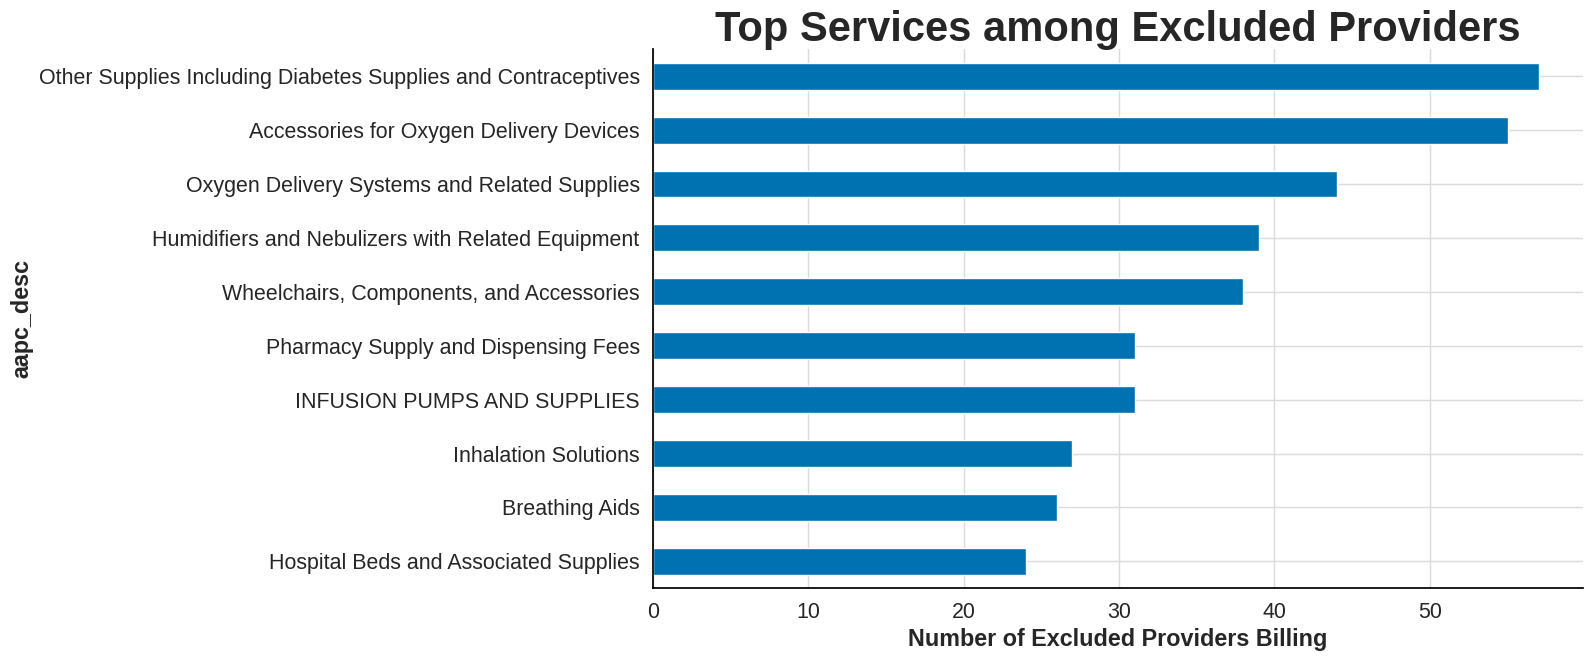

In [18]:
import matplotlib.pyplot as plt

# plot
ax = num_exld_per_desc[hi_risk_desc].plot(kind='barh')
plt.title('Top Services among Excluded Providers')
plt.xlabel('Number of Excluded Providers Billing')
ax.invert_yaxis()
# plt.savefig('excld_prvdr_per_service.png', bbox_inches='tight', dpi=300)
plt.show()

The allcaps "INFUSION PUMPS AND SUPPLIES" denotes Medicare administrative contractors (MACs) DME, i.e. K-series HCPCS code as opposed to typical DME (E-series HCPCS).

In [19]:
import re

# prepare the to_snake_case function
def to_snake_case(name: str) -> str:
    # Add underscore between lower-to-upper transitions
    name = re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', name)
    name = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', name)

    # Replace non-alphanumeric with underscores
    name = re.sub(r'[^0-9a-zA-Z]+', '_', name)

    # Remove leading/trailing underscores and lowercase
    return name.strip("_").lower()

In [20]:
# only records with a high-risk service
df_hi_risk = df_validate[df_validate['aapc_desc'].isin(hi_risk_desc)].filter(items=['npi','year','tot_suplr_clms','aapc_desc'])
# group by npi, year, and aapc_desc
df_hi_risk = df_hi_risk.groupby(['npi','year','aapc_desc'], as_index=False)
# sum groups
df_hi_risk = df_hi_risk.sum()
# snake-case aapc_desc
df_hi_risk['aapc_desc'] = df_hi_risk.aapc_desc.apply(to_snake_case)
# pivot
df_hi_risk = pd.pivot_table(df_hi_risk, values='tot_suplr_clms', index=['npi','year'], columns=["aapc_desc"]).reset_index()
# fill nulls with 0
df_hi_risk = df_hi_risk.fillna(0)
# join w/ df_eng
df_eng = df_eng.merge(df_hi_risk, how='left', on=['npi','year'])
# fill na's w/ 0s
df_eng.loc[:,'accessories_for_oxygen_delivery_devices':'wheelchairs_components_and_accessories'] = df_eng.loc[:,'accessories_for_oxygen_delivery_devices':'wheelchairs_components_and_accessories'].fillna(0)

In [21]:
# print the column names
df_hi_risk.columns[2:]

Index(['accessories_for_oxygen_delivery_devices', 'breathing_aids',
       'hospital_beds_and_associated_supplies',
       'humidifiers_and_nebulizers_with_related_equipment',
       'infusion_pumps_and_supplies', 'inhalation_solutions',
       'other_supplies_including_diabetes_supplies_and_contraceptives',
       'oxygen_delivery_systems_and_related_supplies',
       'pharmacy_supply_and_dispensing_fees',
       'wheelchairs_components_and_accessories'],
      dtype='object', name='aapc_desc')

## Pull in the provider-level data for beneficiary demographic data

In [22]:
rfrr = pd.read_csv('/dsa/groups/casestudycf25/team02/silver/dmepos_rfrr_labeled.csv',dtype={'rfrg_prvdr_state_fips':str,'rfrg_prvdr_zip5':str}) # ensure Rfrg_Prvdr_State_FIPS & Rfrg_Prvdr_Zip5 are imported as str
rfrr.head()

,npi,rfrg_prvdr_last_name_org,rfrg_prvdr_first_name,rfrg_prvdr_mi,rfrg_prvdr_crdntls,rfrg_prvdr_ent_cd,rfrg_prvdr_st1,rfrg_prvdr_st2,rfrg_prvdr_city,rfrg_prvdr_state_abrvtn,rfrg_prvdr_state_fips,rfrg_prvdr_zip5,rfrg_prvdr_ruca,rfrg_prvdr_ruca_desc,rfrg_prvdr_cntry,rfrg_prvdr_spclty_desc,rfrg_prvdr_spclty_srce,tot_suplrs,tot_suplr_hcpcs_cds,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,suplr_sbmtd_chrgs,suplr_mdcr_alowd_amt,suplr_mdcr_pymt_amt,suplr_mdcr_stdzd_pymt_amt,dme_sprsn_ind,dme_tot_suplrs,dme_tot_suplr_hcpcs_cds,dme_tot_suplr_benes,dme_tot_suplr_clms,dme_tot_suplr_srvcs,dme_suplr_sbmtd_chrgs,dme_suplr_mdcr_alowd_amt,dme_suplr_mdcr_pymt_amt,dme_suplr_mdcr_stdzd_pymt_amt,pos_sprsn_ind,pos_tot_suplrs,pos_tot_suplr_hcpcs_cds,pos_tot_suplr_benes,pos_tot_suplr_clms,pos_tot_suplr_srvcs,pos_suplr_sbmtd_chrgs,pos_suplr_mdcr_alowd_amt,pos_suplr_mdcr_pymt_amt,pos_suplr_mdcr_stdzd_pymt_amt,drug_sprsn_ind,drug_tot_suplrs,drug_tot_suplr_hcpcs_cds,drug_tot_suplr_benes,drug_tot_suplr_clms,drug_tot_suplr_srvcs,drug_suplr_sbmtd_chrgs,drug_suplr_mdcr_alowd_amt,drug_suplr_mdcr_pymt_amt,drug_suplr_mdcr_stdzd_pymt_amt,bene_avg_age,bene_age_lt_65_cnt,bene_age_65_74_cnt,bene_age_75_84_cnt,bene_age_gt_84_cnt,bene_feml_cnt,bene_male_cnt,bene_race_wht_cnt,bene_race_black_cnt,bene_race_api_cnt,bene_race_hspnc_cnt,bene_race_natind_cnt,bene_race_othr_cnt,bene_ndual_cnt,bene_dual_cnt,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_depress_v1_pct,bene_cc_bh_pd_v1_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_afib_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre,year,target
0,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,1.0,Metropolitan area core: primary flow within an...,US,Internal Medicine,Claim-Specialty,9,16,12.0,38,95,16659.18,4554.39,3515.05,3827.20,NaN,9.0,16.0,12.0,38.0,95.0,16659.180,4554.39,3515.05,3827.200,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.750000,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.000000,1.000000,-1.0,-1.0,0.0,-1.0,-1.0,1.942167,2021,0
1,1003000480,Rothchild,Kevin,B,md,I,12605 E 16th Ave,NaN,Aurora,CO,08,80045,1.0,Metropolitan area core: primary flow within an...,US,General Surgery,Claim-Specialty,4,3,5.0,11,24,4863.99,1353.37,1082.62,1360.53,NaN,4.0,3.0,5.0,11.0,24.0,4863.990,1353.37,1082.62,1360.530,NaN,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,68.200000,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,-1.0,2.278200,2021,0
2,1003000522,Weigand,Frederick,J,md,I,1565 Saxon Blvd,Suite 102,Deltona,FL,12,32725,1.1,Secondary flow 30% to <50% to a larger urbaniz...,US,Family Practice,NPPES-Specialty,10,22,13.0,47,201,11438.01,2469.17,1846.10,2103.95,NaN,9.0,16.0,12.0,44.0,135.0,10671.850,1911.33,1405.54,1603.420,*,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,*,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.923077,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,13.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,-1.0,1.000000,0.846154,-1.0,-1.0,0.0,-1.0,-1.0,1.872308,2021,0
3,1003000530,Semonche,Amanda,M,do,I,1021 Park Ave,Suite 203,Quakertown,PA,42,18951,1.0,Metropolitan area core: pri

### Initially tried grouping by NPI. Cells maintained as Raw NB Convert for reference only.

We find 498,197 records when grouping the referring provider level dataset on NPI and fraud class label as opposed to 398,034 in the referring provider and service dataset when grouping by the same features. We elect to inner join the two datasets for analysis.

### Group by NPI-Year

In [23]:
rfrr.columns[56]

'bene_avg_age'

In [24]:
rfrr_cols = rfrr.columns[56:-2] # beneficiary demographic columns

# importand cols for joining added to index
idx = pd.Index(['npi','year','target'])
idx = idx.append(rfrr_cols)

rfrr_fts = rfrr[idx]

In [25]:
# join rfrr to df_eng
df_eng = df_eng.merge(rfrr_fts, on=['npi','year','target']) # provider-level on the left to keep newly engineered features in last cols
df_eng.head()

,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,tot_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,tot_suplr_mdcr_pymt_amt_median,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,tot_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_mean,tot_suplr_benes_mean,tot_suplr_clms_mean,tot_suplr_srvcs_mean,tot_suplrs_sum,tot_suplr_benes_sum,tot_suplr_clms_sum,tot_suplr_srvcs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplr_clms_median,tot_suplr_srvcs_median,tot_suplrs_min,tot_suplr_benes_min,tot_suplr_clms_min,tot_suplr_srvcs_min,tot_suplrs_max,tot_suplr_benes_max,tot_suplr_clms_max,tot_suplr_srvcs_max,cnt_tot_suplr_clms_hcpcs_rentl_ind_pctl_abv_90,cnt_tot_suplr_srvcs_hcpcs_rentl_ind_pctl_abv_90,cnt_tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl_abv_90,accessories_for_oxygen_delivery_devices,breathing_aids,hospital_beds_and_associated_supplies,humidifiers_and_nebulizers_with_related_equipment,infusion_pumps_and_supplies,inhalation_solutions,other_supplies_including_diabetes_supplies_and_contraceptives,oxygen_delivery_systems_and_related_supplies,pharmacy_supply_and_dispensing_fees,wheelchairs_components_and_accessories,bene_avg_age,bene_age_lt_65_cnt,bene_age_65_74_cnt,bene_age_75_84_cnt,bene_age_gt_84_cnt,bene_feml_cnt,bene_male_cnt,bene_race_wht_cnt,bene_race_black_cnt,bene_race_api_cnt,bene_race_hspnc_cnt,bene_race_natind_cnt,bene_race_othr_cnt,bene_ndual_cnt,bene_dual_cnt,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_depress_v1_pct,bene_cc_bh_pd_v1_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_afib_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre
0,1003000126,MD,2021,0,129.776563,41.940392,31.813932,34.260562,514.212500,-0.393302,0.976494,519.106250,167.761567,127.255730,137.042249,2056.85,-1.573206,3.905978,69.168125,29.663750,23.121477,24.416364,291.480,-0.399906,0.970334,20.000000,10.210909,8.169091,8.456364,89.86,-0.425926,0.942913,360.770000,98.223158,72.843684,79.753158,1384.03,-0.347468,1.022396,0.0,4.0,3.250000,5.0,14.250000,14.250000,13,20.0,57,57,3.0,5.0,13.5,13.5,1,5.0,11,11,6,5.0,19,19,0,0,0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,22.0,79.750000,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,1.000000,-1.000000,-1.0,0.0,-1.0,-1.0,1.942167
1,1003000126,MD,2022,0,209.273634,54.750832,41.764741,52.602407,2398.615000,0.164212,0.83548

## Pull in the provider specialty dataset

In [26]:
df_spec = pd.read_csv('/dsa/groups/casestudycf25/team02/silver/one_specialty_per_npi_year.csv') # pull in the provider specialty dataset
df_spec.head()

,Unnamed: 0,rfrg_npi,rfrg_prvdr_spclty_srce,year,specialty_type,specialty_lvl1,specialty,og_specialty_name
0,0,1043273253,NPPES-Taxonomy,2022,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine,Internal Medicine
1,1,1275631657,NPPES-Taxonomy,2022,Other,Other Service Providers,Specialist,Specialist
2,2,1821084567,NPPES-Taxonomy,2023,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine,Internal Medicine
3,3,1821080375,NPPES-Taxonomy,2023,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine,Internal Medicine
4,4,1821219569,NPPES-Taxonomy,2023,Medical Doctor,Allopathic & Osteopathic Physicians,Obstetrics and Gynecology,Obstetrics & Gynecology


### Drop unnecessary columns and join to df_eng by npi and year

In [27]:
df_spec = df_spec[['rfrg_npi','year','og_specialty_name']]
df_eng = df_eng.merge(df_spec, how='left', left_on=['npi','year'], right_on=['rfrg_npi','year'], validate='many_to_one').drop('rfrg_npi', axis=1)
df_eng.head()

,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,tot_suplr_mdcr_pymt_amt_mean,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_mean,avg_suplr_mdcr_alowd_amt_hcpcs_rat_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_stdzd_amt_sum,tot_suplr_mdcr_pymt_amt_sum,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_sum,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_sum,avg_suplr_sbmtd_chrg_median,avg_suplr_mdcr_alowd_amt_median,avg_suplr_mdcr_pymt_amt_median,avg_suplr_mdcr_stdzd_amt_median,tot_suplr_mdcr_pymt_amt_median,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_median,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_median,avg_suplr_sbmtd_chrg_min,avg_suplr_mdcr_alowd_amt_min,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_stdzd_amt_min,tot_suplr_mdcr_pymt_amt_min,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_min,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_min,avg_suplr_sbmtd_chrg_max,avg_suplr_mdcr_alowd_amt_max,avg_suplr_mdcr_pymt_amt_max,avg_suplr_mdcr_stdzd_amt_max,tot_suplr_mdcr_pymt_amt_max,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr_max,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_mean,tot_suplr_benes_mean,tot_suplr_clms_mean,tot_suplr_srvcs_mean,tot_suplrs_sum,tot_suplr_benes_sum,tot_suplr_clms_sum,tot_suplr_srvcs_sum,tot_suplrs_median,tot_suplr_benes_median,tot_suplr_clms_median,tot_suplr_srvcs_median,tot_suplrs_min,tot_suplr_benes_min,tot_suplr_clms_min,tot_suplr_srvcs_min,tot_suplrs_max,tot_suplr_benes_max,tot_suplr_clms_max,tot_suplr_srvcs_max,cnt_tot_suplr_clms_hcpcs_rentl_ind_pctl_abv_90,cnt_tot_suplr_srvcs_hcpcs_rentl_ind_pctl_abv_90,cnt_tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_pctl_abv_90,accessories_for_oxygen_delivery_devices,breathing_aids,hospital_beds_and_associated_supplies,humidifiers_and_nebulizers_with_related_equipment,infusion_pumps_and_supplies,inhalation_solutions,other_supplies_including_diabetes_supplies_and_contraceptives,oxygen_delivery_systems_and_related_supplies,pharmacy_supply_and_dispensing_fees,wheelchairs_components_and_accessories,bene_avg_age,bene_age_lt_65_cnt,bene_age_65_74_cnt,bene_age_75_84_cnt,bene_age_gt_84_cnt,bene_feml_cnt,bene_male_cnt,bene_race_wht_cnt,bene_race_black_cnt,bene_race_api_cnt,bene_race_hspnc_cnt,bene_race_natind_cnt,bene_race_othr_cnt,bene_ndual_cnt,bene_dual_cnt,bene_cc_bh_adhd_oth_cd_v1_pct,bene_cc_bh_alcohol_drug_v1_pct,bene_cc_bh_tobacco_v1_pct,bene_cc_bh_alz_non_alzdem_v2_pct,bene_cc_bh_anxiety_v1_pct,bene_cc_bh_bipolar_v1_pct,bene_cc_bh_mood_v2_pct,bene_cc_bh_depress_v1_pct,bene_cc_bh_pd_v1_pct,bene_cc_bh_ptsd_v1_pct,bene_cc_bh_schizo_oth_psy_v1_pct,bene_cc_ph_asthma_v2_pct,bene_cc_ph_afib_v2_pct,bene_cc_ph_cancer6_v2_pct,bene_cc_ph_ckd_v2_pct,bene_cc_ph_copd_v2_pct,bene_cc_ph_diabetes_v2_pct,bene_cc_ph_hf_non_ihd_v2_pct,bene_cc_ph_hyperlipidemia_v2_pct,bene_cc_ph_hypertension_v2_pct,bene_cc_ph_ischemic_heart_v2_pct,bene_cc_ph_osteoporosis_v2_pct,bene_cc_ph_parkinson_v2_pct,bene_cc_ph_arthritis_v2_pct,bene_cc_ph_stroke_tia_v2_pct,bene_avg_risk_scre,og_specialty_name
0,1003000126,MD,2021,0,129.776563,41.940392,31.813932,34.260562,514.212500,-0.393302,0.976494,519.106250,167.761567,127.255730,137.042249,2056.85,-1.573206,3.905978,69.168125,29.663750,23.121477,24.416364,291.480,-0.399906,0.970334,20.000000,10.210909,8.169091,8.456364,89.86,-0.425926,0.942913,360.770000,98.223158,72.843684,79.753158,1384.03,-0.347468,1.022396,0.0,4.0,3.250000,5.0,14.250000,14.250000,13,20.0,57,57,3.0,5.0,13.5,13.5,1,5.0,11,11,6,5.0,19,19,0,0,0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,22.0,79.750000,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.000000,1.000000,-1.000000,-1.0,0.0,-1.0,-1.0,1.942167,Internal Medicine
1,1003000126,MD,2022,0,209.273634,54.750832,41.764741,52

### Convert og_specialty_name to snake case

In [28]:
# transform the data
df_eng['og_specialty_name'] = df_eng.og_specialty_name.apply(to_snake_case)

Previously needed to reshape the dataframe to put the years and the fraud class labels in the second and third columns. Code converted to markdown because rework made this redundant.

In [29]:
df_eng.shape

(879531, 116)

### One-hot encode the specialty descriptions

On February 26, 2026 we determined that one-hot encoding spcialty descriptions was not appropriate for the analysis we intended to perform. Code cells have been changed to Raw NBConvert to be retained for reference only.

## Filter for Missouri and bordering states

In [30]:
df_eng = df_eng[df_eng.rfrg_prvdr_state_abrvtn.isin(['MO', 'IL', 'IA', 'OK', 'AR', 'TN', 'KS', 'NE', 'KY'])]

In [31]:
df_eng.shape

(140827, 116)

## Save the filtered dataset

In [32]:
# save df_eng as a csv
df_eng.to_csv('/dsa/groups/casestudycf25/team02/silver/dmepos_amount_stats_labeled.csv', index=False)